# Model Training and Evaluation

In this notebook, I build a machine learning model to classify news articles as REAL or FAKE.

The workflow includes:
- loading the cleaned dataset
- transforming text into numerical features using TF-IDF
- training a Logistic Regression model
- evaluating the model
- testing predictions on custom input

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("../data/clean_data.csv")
df.head()

,title,text,label,content,content_clean
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",FAKE,BREAKING: GOP Chairman Grassley Has Had Enoug...,breaking gop chairman grassley has had enough ...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,FAKE,Failed GOP Candidates Remembered In Hilarious...,failed gop candidates remembered in hilarious ...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,FAKE,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,mike pence’s new dc neighbors are hilariously ...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,REAL,California AG pledges to defend birth control ...,california ag pledges to defend birth control ...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,FAKE,AZ RANCHERS Living On US-Mexico Border Destroy...,az ranchers living on usmexico border destroy ...


In [2]:
df.shape

(39105, 5)

In [3]:
df.columns

Index(['title', 'text', 'label', 'content', 'content_clean'], dtype='object')

## Defining Input and Target

For this model:
- `X` will contain the cleaned text
- `y` will contain the labels (REAL or FAKE)

In [4]:
X = df["content_clean"]
y = df["label"]

In [5]:
X.head()

0    breaking gop chairman grassley has had enough ...
1    failed gop candidates remembered in hilarious ...
2    mike pence’s new dc neighbors are hilariously ...
3    california ag pledges to defend birth control ...
4    az ranchers living on usmexico border destroy ...
Name: content_clean, dtype: object

In [6]:
y.head()

0    FAKE
1    FAKE
2    FAKE
3    REAL
4    FAKE
Name: label, dtype: object

## Train-Test Split

I split the dataset into:
- training data, used to train the model
- testing data, used to evaluate performance on unseen examples

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train = X_train.fillna("").astype(str)
X_test = X_test.fillna("").astype(str)

In [9]:
# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (31284,)
X_test shape: (7821,)
y_train shape: (31284,)
y_test shape: (7821,)


## TF-IDF Vectorization

Machine learning models cannot work directly with raw text.

To convert text into numerical form, I use TF-IDF, which gives importance to words based on:
- how often they appear in a document
- how rare they are across the dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39105 entries, 0 to 39104
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          39105 non-null  object
 1   text           39105 non-null  object
 2   label          39105 non-null  object
 3   content        39105 non-null  object
 4   content_clean  39100 non-null  object
dtypes: object(5)
memory usage: 1.5+ MB


In [11]:
print(X_train.head())
print(type(X_train))

4962     wow social media freaks out over what’s behind...
21349    eu not working on no deal scenario for brexit ...
38488    saudi arabia to vet use of prophets sayings to...
14930    senate rejects new us retirement rule obama re...
16477    james clapper just publicly said trump is dest...
Name: content_clean, dtype: object
<class 'pandas.core.series.Series'>


In [12]:
vectorizer = TfidfVectorizer(stop_words="english")

In [13]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [14]:
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (31284, 174321)
X_test_tfidf shape: (7821, 174321)


## Training the Model

I use Logistic Regression as a baseline model for this classification task.

It is a strong and simple model for text classification problems.

In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Make prediction

In [16]:
y_pred = model.predict(X_test_tfidf)

In [17]:
# check a few precitctions
print(y_pred[:10])

['REAL' 'REAL' 'FAKE' 'REAL' 'FAKE' 'REAL' 'REAL' 'FAKE' 'REAL' 'FAKE']


## Model Evaluation
To evaluate the model, I use:
- accuracy
- classification report
- confusion matrix

## Accuracy

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9836338064186165


## Classification Report



In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.98      3591
        REAL       0.98      0.99      0.98      4230

    accuracy                           0.98      7821
   macro avg       0.98      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821



## Confusion matrix

In [20]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3511   80]
 [  48 4182]]


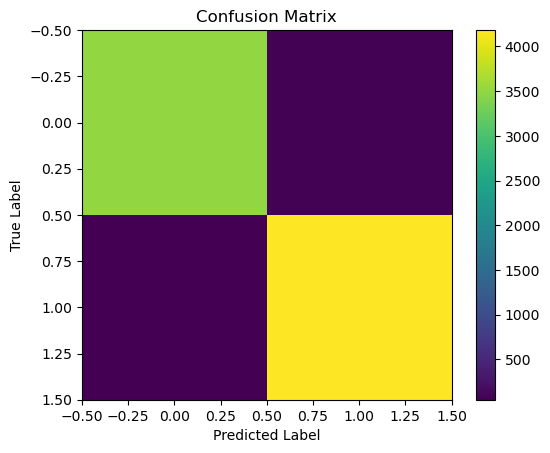

In [21]:
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [22]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\[.*?\]", "", text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>+", "", text)
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\w*\d\w*", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

## Testing the Model on New Input

Finally, I create a function that allows me to test the model on custom text input.

In [23]:
def predict_news(text):
    cleaned_text = clean_text(text)
    vectorized_text = vectorizer.transform([cleaned_text])
    prediction = model.predict(vectorized_text)[0]
    return prediction

## Test Custom Examples

In [24]:
sample_news_1 = "Government confirms new economic reforms after a parliamentary meeting."
print("Prediction 1:", predict_news(sample_news_1))

Prediction 1: REAL


In [25]:
sample_texts = [
    # REAL-style
    "The government announced new economic reforms during a parliamentary session, focusing on improving infrastructure and increasing investments in renewable energy. Officials stated that these changes aim to boost economic growth and create more job opportunities in the coming years.",

    "International leaders met this week to discuss climate change policies and global cooperation strategies. The meeting highlighted the importance of reducing carbon emissions and investing in sustainable technologies to address environmental challenges.",

    "Health authorities confirmed a decrease in infection rates after the implementation of new public health measures. Experts believe that vaccination campaigns and awareness programs have contributed significantly to this improvement.",

    # FAKE-style
    "A shocking secret has been revealed claiming that scientists have been hiding a cure for major diseases for decades. According to anonymous sources, powerful organizations are preventing this information from reaching the public to maintain control.",

    "An unbelievable discovery suggests that ancient civilizations had access to advanced technology far beyond modern understanding. Some theories claim that this knowledge has been intentionally suppressed by global elites.",

    "Reports are circulating online that a group of insiders has exposed a hidden plan involving world leaders manipulating global events. The claims, although unverified, have gained massive attention across social media platforms."
]

predictions = [predict_news(text) for text in sample_texts]

results_df = pd.DataFrame({
    "text": sample_texts,
    "prediction": predictions
})

results_df

,text,prediction
0,The government announced new economic reforms ...,REAL
1,International leaders met this week to discuss...,REAL
2,Health authorities confirmed a decrease in inf...,FAKE
3,A shocking secret has been revealed claiming t...,FAKE
4,An unbelievable discovery suggests that ancien...,FAKE
5,Reports are circulating online that a group of...,FAKE


## Conclusion

The model performs well on the fake news classification task using TF-IDF and Logistic Regression.

This notebook shows the complete machine learning pipeline:
- text preprocessing
- feature extraction
- model training
- evaluation
- custom prediction

It also serves as a good baseline for future improvements such as trying other models or using more advanced NLP techniques.